In [1]:
import torch
from model import CNN
from contrastive import ContrastiveLearning
from ebt import EBTTrainer
import omegaconf 
import matplotlib.pyplot as plt
from langevin import *
import torchvision

In [7]:
conf = omegaconf.OmegaConf.load("./config.yaml")
model = EBTTrainer(CNN(conf), conf)
with open("./checkpoints/ebt.pth", "rb") as f:
    model.load_state_dict(torch.load(f, map_location="cuda"))

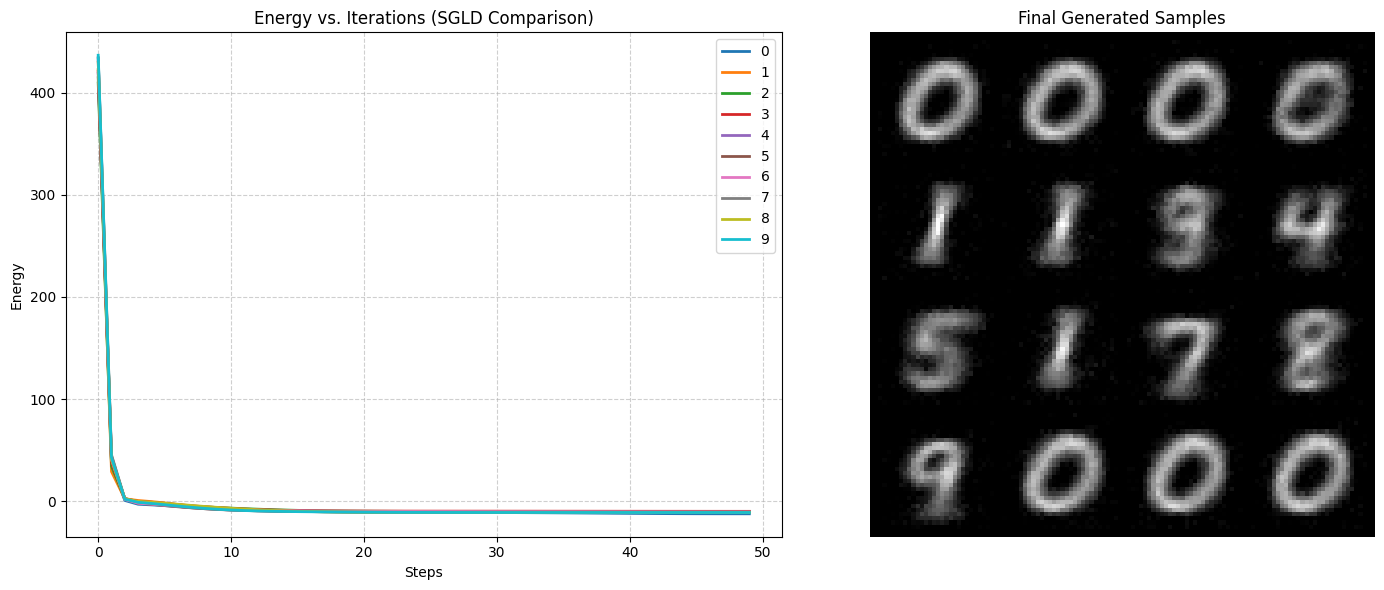

In [11]:

import matplotlib.pyplot as plt

def plot_results(samples, energy_histories):
    """
    Displays the energy convergence for multiple runs and the final sampled images.
    
    Args:
        samples (Tensor): The final batch of images to display.
        energy_histories (dict): A dictionary where keys are labels (strings) 
                                 and values are lists of energy values.
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Plot multiple Energy Curves
    for label, history in energy_histories.items():
        ax[0].plot(history, label=label, linewidth=2)
    
    ax[0].set_title("Energy vs. Iterations (SGLD Comparison)")
    ax[0].set_xlabel("Steps")
    ax[0].set_ylabel("Energy")
    ax[0].grid(True, linestyle='--', alpha=0.6)
    ax[0].legend() # Added legend to distinguish the lines
    
    # 2. Plot Image Grid
    ax[1].set_title("Final Generated Samples")
    # Rescale from [-1, 1] to [0, 1] for visualization
    grid_img = torchvision.utils.make_grid(samples, nrow=4, normalize=True, padding=2)
    
    # Move channels to the end for matplotlib (C, H, W -> H, W, C)
    img_np = grid_img.permute(1, 2, 0).cpu().numpy()
    
    ax[1].imshow(img_np)
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example Usage:
# samples, energies = my_model.sample_with_energy_track(steps=60, step_size=10, noise_scale=0.005)
# plot_results(samples, energies)

total_samples = None
total_energies = {}
for i in range(10):
    #if i in [0,3,4,5,6,7,9]:
    #    continue

    samples, info = model.sample_langevin(
        num_samples=16,
        condition=torch.full((16,), i).to("cuda"),
        stop_method=StopStep(max_steps=50),
        step_size=5,
        noise_scale=0.05,
        gradient_method=GradientMethod.NONE,
        ret_extra=True,
        device="cuda"
    )
    total_energies[i] = info["energy_history"].mean(-1).cpu().numpy()
    if total_samples is None:
        total_samples = samples
    else:
        total_samples[i+3] = samples[i+3]
plot_results(total_samples, total_energies)